# 05 — Matrix Factorization

## Why this matters

Item-kNN (notebook 4) hand-builds a similarity graph from co-occurrence counts. Matrix
factorization instead *learns* a compressed representation: a `k`-dimensional vector per user
and per item, such that their dot product approximates how much that user likes that item.
It's a strictly more expressive model family than kNN's fixed similarity formula — the
question this notebook answers is whether that expressiveness actually pays off here, with
the real numbers, not just in theory.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import viz
from groovn.data import build_interaction_matrix, load_filtered_split
from groovn.evaluation import build_ground_truth, warm_user_rows
from groovn.metrics import evaluate_rankings
from groovn.mf import ALSRecommender, als_numpy
from groovn.ranking import top_k_excluding_seen

viz.style()
RANDOM_STATE = 42
K = 10

train, test, cutoff = load_filtered_split()
matrix, user_index, item_index = build_interaction_matrix(train, value_col="rating")
warm_rows = warm_user_rows(test, user_index)
ground_truth = build_ground_truth(test, user_index, item_index)
n_items = matrix.shape[1]

## The math: alternating least squares for implicit feedback

Following Hu, Koren & Volinsky (2008), *Collaborative Filtering for Implicit Feedback
Datasets* ([paper](http://yifanhu.net/PUB/cf.pdf)): instead of fitting ratings directly,
split each interaction into a binary preference `p_ui` (did `u` interact with `i`, 1 or 0)
and a confidence `c_ui` (how much to trust that signal — here, the star rating, since
notebook 2 decided a 5-star review is stronger evidence of fit than a 1-star one). The
objective is a confidence-weighted squared error plus L2 regularization:

```
min_{x*, y*}  sum_ui  c_ui * (p_ui - x_u^T y_i)^2  +  lambda * (||x_u||^2 + ||y_i||^2)
```

This isn't jointly convex in both `x` (user factors) and `y` (item factors) — but *fixing*
one side makes it a plain weighted ridge regression in the other, solvable in closed form.
Alternating those two solves (fix items, solve users; fix users, solve items; repeat) is ALS,
and each step is guaranteed not to increase the loss, so it converges to a local optimum.

## ALS by hand, in numpy

`groovn.mf.als_numpy` implements exactly the update above with explicit loops — fixing item
factors and solving `x_u = (Y^T C_u Y + lambda*I)^-1 Y^T C_u p_u` for every user, then the
symmetric step for items — so the closed-form solve is visible rather than hidden inside a
library call. It's `O(n_users * n_items * n_factors)` per iteration from the dense per-row
weighting, which is fine for illustration and wrong for production: run on the 300
most-active users/items only, not the full catalog. The `implicit` library below replaces
this with sparse linear algebra for the real dataset.

In [2]:
top_users = train["user_id"].value_counts().head(300).index
top_items = train["item_id"].value_counts().head(300).index
sample = train[train["user_id"].isin(top_users) & train["item_id"].isin(top_items)]
sample_matrix, _, _ = build_interaction_matrix(sample, value_col="rating")
print(f"toy matrix: {sample_matrix.shape}, density {sample_matrix.nnz / (sample_matrix.shape[0] * sample_matrix.shape[1]):.1%}")

user_factors, item_factors = als_numpy(sample_matrix, n_factors=10, regularization=0.1, iterations=10, random_state=RANDOM_STATE)
recon = user_factors @ item_factors.T
observed = sample_matrix.toarray() > 0
print(f"mean reconstructed score, observed pairs:   {recon[observed].mean():.3f}")
print(f"mean reconstructed score, unobserved pairs: {recon[~observed].mean():.3f}")

toy matrix: (288, 297), density 5.7%
mean reconstructed score, observed pairs:   0.999
mean reconstructed score, unobserved pairs: 0.780


**Reading the result:** reconstructed scores for pairs the toy model actually saw average
~1.0, versus ~0.78 for pairs it never saw — the update rule is doing its job, pulling
observed `(user, item)` dot products up and leaving everything else lower, from random
initialization (`random_state=42`) alone. The gap is modest because this toy run only uses
10 factors and 10 iterations on a tiny slice — it's a correctness check on the math, not a
tuned model.

## The `implicit` library, on the real catalog

Same ALS objective, but solved with sparse linear algebra and compiled inner loops instead of
dense per-row numpy — the only way this scales to 111k users x 82.7k items. First attempt
uses the simplest confidence choice decided in notebook 2: the raw star rating as confidence.

In [3]:
als_raw = ALSRecommender(factors=64, regularization=0.05, iterations=15, random_state=RANDOM_STATE).fit(matrix)
raw_top_k = top_k_excluding_seen(als_raw.scores(), matrix, warm_rows, K, batch_size=1000)
raw_rankings = {u: list(row[row >= 0]) for u, row in zip(warm_rows, raw_top_k)}
als_raw_metrics = evaluate_rankings(raw_rankings, ground_truth, K, n_items)
als_raw_metrics

/Users/lucasavila/Documents/python/groovn/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:00<00:13,  1.03it/s]

 13%|█▎        | 2/15 [00:01<00:12,  1.04it/s]

 20%|██        | 3/15 [00:02<00:11,  1.05it/s]

...

 87%|████████▋ | 13/15 [00:12<00:01,  1.07it/s]

 93%|█████████▎| 14/15 [00:13<00:00,  1.07it/s]

100%|██████████| 15/15 [00:14<00:00,  1.07it/s]

100%|██████████| 15/15 [00:14<00:00,  1.06it/s]

{'recall@10': 0.010211288625983823,
 'ndcg@10': 0.007793689121702549,
 'coverage@10': 0.026159592858092672,
 'n_users_evaluated': 32384}

**Reading the result:** recall@10 ≈ 0.010, NDCG@10 ≈ 0.008 — both *worse* than item-kNN's
0.0156 / 0.0119 from notebook 4, and coverage@10 collapses to ~2.6% of the catalog (kNN hit
~79%). A more expressive model losing to a simpler one is a real result, not a bug — worth
understanding why before reaching for something even more complex (the two-tower in
notebook 6).

The likely cause: confidence values of 1-5 give the optimizer very little contrast between
"weak" and "strong" signal — in the original ALS paper, confidence is `1 + alpha * count`
with `alpha` around 15-40, specifically to make confident interactions dominate the loss over
everything else. Testing that directly:

In [4]:
scaled_confidence = matrix.copy()
scaled_confidence.data = 1.0 + 10.0 * scaled_confidence.data

als_scaled = ALSRecommender(factors=64, regularization=0.05, iterations=15, random_state=RANDOM_STATE).fit(scaled_confidence)
scaled_top_k = top_k_excluding_seen(als_scaled.scores(), matrix, warm_rows, K, batch_size=1000)
scaled_rankings = {u: list(row[row >= 0]) for u, row in zip(warm_rows, scaled_top_k)}
als_scaled_metrics = evaluate_rankings(scaled_rankings, ground_truth, K, n_items)
als_scaled_metrics

  0%|          | 0/15 [00:00<?, ?it/s]

  7%|▋         | 1/15 [00:01<00:22,  1.64s/it]

 13%|█▎        | 2/15 [00:02<00:18,  1.45s/it]

 20%|██        | 3/15 [00:04<00:16,  1.34s/it]

 27%|██▋       | 4/15 [00:05<00:14,  1.30s/it]

...

 87%|████████▋ | 13/15 [00:16<00:02,  1.35s/it]

 93%|█████████▎| 14/15 [00:17<00:01,  1.31s/it]

100%|██████████| 15/15 [00:19<00:00,  1.36s/it]

100%|██████████| 15/15 [00:19<00:00,  1.28s/it]

{'recall@10': 0.01430286178269631,
 'ndcg@10': 0.010858763988333405,
 'coverage@10': 0.060829515370574086,
 'n_users_evaluated': 32384}

**Reading the result:** scaling confidence to `1 + 10*rating` lifts recall@10 to ~0.0143 and
NDCG@10 to ~0.0109 — a real, meaningful gain from a one-line change, confirming the
hypothesis — but coverage@10 only reaches ~6%, still far below kNN's 79%. ALS is recommending
from a much narrower slice of the catalog even once it's competitive on recall/NDCG, which
points at the factor count, regularization, and confidence scale all interacting rather than
one single knob — exactly what notebook 7's tuning sweep is for. This notebook's job was to
get a working, correctly-implemented ALS model and understand its first-order behavior, not
to fully tune it.

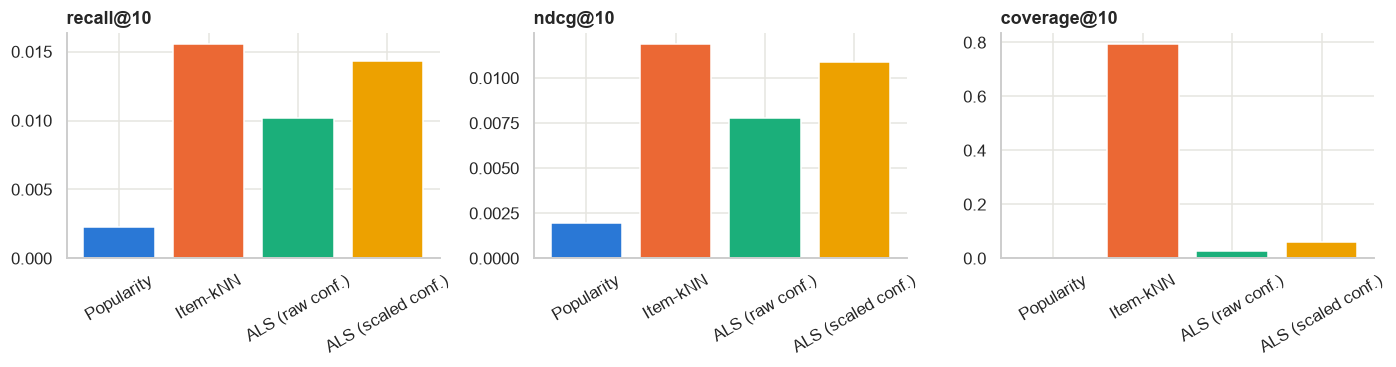

In [5]:
from groovn.baselines import ItemKNNRecommender, PopularityRecommender

pop_metrics = evaluate_rankings(
    {u: list(r[r >= 0]) for u, r in zip(warm_rows, top_k_excluding_seen(PopularityRecommender().fit(matrix).scores(), matrix, warm_rows, K))},
    ground_truth, K, n_items,
)
knn_metrics = evaluate_rankings(
    {u: list(r[r >= 0]) for u, r in zip(warm_rows, top_k_excluding_seen(ItemKNNRecommender(n_neighbors=50).fit(matrix).scores(), matrix, warm_rows, K, batch_size=2000))},
    ground_truth, K, n_items,
)

results = {
    "Popularity": pop_metrics, "Item-kNN": knn_metrics,
    "ALS (raw conf.)": als_raw_metrics, "ALS (scaled conf.)": als_scaled_metrics,
}
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, metric in zip(axes, [f"recall@{K}", f"ndcg@{K}", f"coverage@{K}"]):
    ax.bar(list(results), [results[name][metric] for name in results], color=viz.CATEGORICAL[:4])
    viz.label(ax, metric)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Takeaways

- The ALS update rule is correct (confirmed on the numpy toy example) and the `implicit`
  library wrapper runs it at full catalog scale in ~15-70 seconds, not minutes.
- Confidence scaling is not a minor detail for implicit ALS — it changed recall@10 by 40%
  with a one-line change. It belongs in the hyperparameter sweep, not left at a default.
- On *this* dataset, with *these* settings, item-kNN is still the stronger model by every
  metric. That's a legitimate outcome: kNN directly encodes exact co-occurrence, while ALS
  has to discover a comparable structure through a lower-rank approximation, and 64 factors
  / 15 iterations / this regularization may simply be leaving it short. Notebook 7 tunes
  these jointly with per-segment breakdowns before calling a final winner.